In [1]:
# ==============================================================================
# STEP 1: WORKSPACE SETUP & LIVE WEB INGESTION
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean visualization theme parameters
sns.set_theme(style="whitegrid")

# Directly ingest dataset from the live production repository link
dataset_url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(dataset_url)

# Display data dimensional baseline structure
print("--- TELECOM CHURN PIPELINE DATASET SNAPSHOT ---")
print(f"Total Customer Records: {df.shape[0]}")
print(f"Total Feature Parameters: {df.shape[1]}\n")
df.head()

--- TELECOM CHURN PIPELINE DATASET SNAPSHOT ---
Total Customer Records: 7043
Total Feature Parameters: 21



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# ==============================================================================
# STEP 2: METADATA & DATA VALIDATION PROFILE
# ==============================================================================

print("--- PIPELINE RAW METADATA DETAILS ---")
df.info()

print("\n--- TARGET VARIABLE VALUE COUNT DENSITY ---")
print(df['Churn'].value_counts(normalize=True) * 100)

--- PIPELINE RAW METADATA DETAILS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Pape

In [3]:
# ==============================================================================
# STEP 3: LOGICAL TEXT CONVERSION & MISSING VALUE PROCESSING
# ==============================================================================

# Create a clean processing copy of our streamed telecom dataframe
processed_df = df.copy()

# 1. Drop the unique identifier column as it possesses zero statistical predictive value
if 'customerID' in processed_df.columns:
    processed_df.drop(columns=['customerID'], inplace=True)

# 2. Convert 'TotalCharges' from raw string to numerical float elements
# Coerce invalid/empty spaces string entries to numerical NaN representations
processed_df['TotalCharges'] = pd.to_numeric(processed_df['TotalCharges'], errors='coerce')

# 3. Handle generated null instances within TotalCharges via median values
processed_df['TotalCharges'] = processed_df['TotalCharges'].fillna(processed_df['TotalCharges'].median())

# 4. Map the Target Label 'Churn' from text string representations to mathematical 0 and 1 vectors
processed_df['Churn'] = processed_df['Churn'].map({'No': 0, 'Yes': 1})

# Output transformed structural parameters to ensure correctness
print("--- DATA TRANSLATION AND STRUCTURAL VALUE VERIFICATION COMPLETE ---")
print(f"Current Target Verification (Value Densities):\n{processed_df['Churn'].value_counts()}")
processed_df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].head()

--- DATA TRANSLATION AND STRUCTURAL VALUE VERIFICATION COMPLETE ---
Current Target Verification (Value Densities):
Churn
0    5174
1    1869
Name: count, dtype: int64


,tenure,MonthlyCharges,TotalCharges,Churn
0,1,29.85,29.85,0
1,34,56.95,1889.50,0
2,2,53.85,108.15,1
3,45,42.30,1840.75,0
4,2,70.70,151.65,1


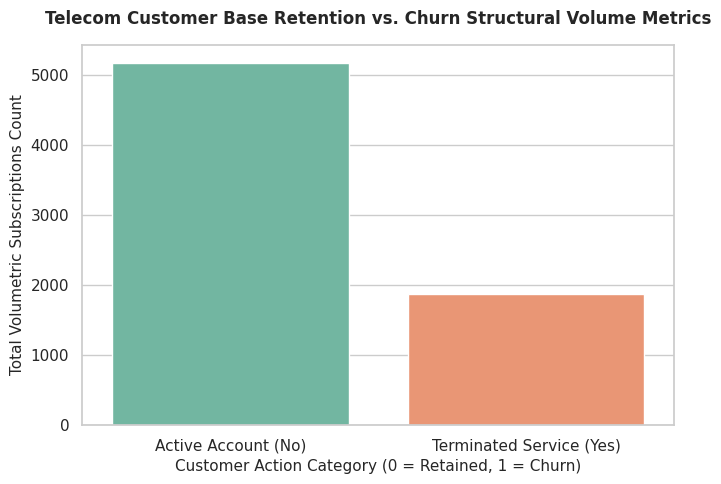

In [4]:
# ==============================================================================
# STEP 4: EXPLORATORY VISUALIZATION ENGINE (CHURN VOLUME DISTRIBUTION)
# ==============================================================================

plt.figure(figsize=(7, 5))
# Generate a clean professional count plot highlighting churn volumetric ratio split
sns.countplot(x='Churn', data=processed_df, hue='Churn', palette='Set2', legend=False)
plt.title('Telecom Customer Base Retention vs. Churn Structural Volume Metrics', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Customer Action Category (0 = Retained, 1 = Churn)', fontsize=11)
plt.ylabel('Total Volumetric Subscriptions Count', fontsize=11)
plt.xticks(ticks=[0, 1], labels=['Active Account (No)', 'Terminated Service (Yes)'])
plt.tight_layout()
plt.show()

In [5]:
# ==============================================================================
# STEP 5: CATEGORICAL HOT-ENCODING & SCALED STRUCTURAL SPLITTING
# ==============================================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Convert all text/categorical features into optimized dummy binary arrays dynamically
encoded_df = pd.get_dummies(processed_df, drop_first=True)

# Separate input attributes (X) from our numeric binary target label (y)
X = encoded_df.drop(columns=['Churn'])
y = encoded_df['Churn']

# Strategically split dataset using stratification to maintain exact class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize numerical ranges to ensure stable architectural gradients
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- MATRIX SPLITTING AND FEATURE STANDARDIZATION METRICS COMPLETE ---")
print(f"Training Subset Dimensions : {X_train_scaled.shape}")
print(f"Testing Subset Dimensions  : {X_test_scaled.shape}")

--- MATRIX SPLITTING AND FEATURE STANDARDIZATION METRICS COMPLETE ---
Training Subset Dimensions : (5634, 30)
Testing Subset Dimensions  : (1409, 30)


In [6]:
# ==============================================================================
# STEP 6: STRATIFIED ENSEMBLE TRAINING (COMPOSITE BOOSTING INTEGRATION)
# ==============================================================================

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

# Initialize individual robust tree estimators with balanced class handling
rf_model = RandomForestClassifier(
    n_estimators=150, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1
)

# Calculate ratio of negative class elements to positive to counteract structural imbalance in XGBoost
scale_pos_weight_value = (len(y_train) - sum(y_train)) / sum(y_train)

xgb_model = XGBClassifier(
    n_estimators=150, learning_rate=0.05, max_depth=5,
    scale_pos_weight=scale_pos_weight_value, random_state=42, n_jobs=-1
)

# Merge structural components into a production Soft-Voting Network Engine
telecom_ensemble_pipeline = VotingClassifier(
    estimators=[
        ('random_forest_clf', rf_model),
        ('xgboost_clf', xgb_model)
    ],
    voting='soft'
)

print("Executing comprehensive mathematical training over multi-dimensional feature space...")
telecom_ensemble_pipeline.fit(X_train_scaled, y_train)
print("--- TELECOM ENSEMBLINE CLASSIFIER MATRIX TRAINED SUCCESSFULLY ---")

Executing comprehensive mathematical training over multi-dimensional feature space...
--- TELECOM ENSEMBLINE CLASSIFIER MATRIX TRAINED SUCCESSFULLY ---


           ENTERPRISE CUSTOMER CHURN PIPELINE EVALUATION              
Global Receiver Operating Area Metric (ROC-AUC): 0.8429

Detailed Precision, Recall, and F1 Performance Arrays:
                  precision    recall  f1-score   support

Retained Account       0.90      0.76      0.83      1035
 Churned Account       0.54      0.77      0.64       374

        accuracy                           0.77      1409
       macro avg       0.72      0.77      0.73      1409
    weighted avg       0.81      0.77      0.78      1409



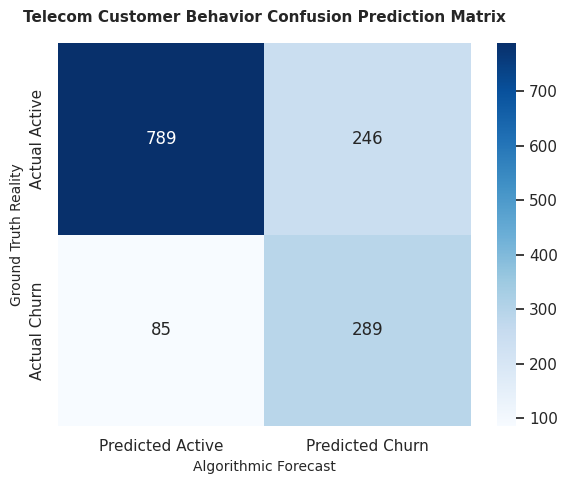

In [7]:
# ==============================================================================
# STEP 7: COMPREHENSIVE CLASSIFICATION VALIDATION & VISUALIZATION
# ==============================================================================

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Extract target predictions over unseen testing partitions
y_pred = telecom_ensemble_pipeline.predict(X_test_scaled)
y_proba = telecom_ensemble_pipeline.predict_proba(X_test_scaled)[:, 1]

# Display enterprise baseline statistical metrics
print("======================================================================")
print("           ENTERPRISE CUSTOMER CHURN PIPELINE EVALUATION              ")
print("======================================================================")
print(f"Global Receiver Operating Area Metric (ROC-AUC): {roc_auc_score(y_test, y_proba):.4f}\n")
print("Detailed Precision, Recall, and F1 Performance Arrays:")
print(classification_report(y_test, y_pred, target_names=['Retained Account', 'Churned Account']))
print("======================================================================")

# Generate a visually rich graphical matrix tracking accurate hits and false points
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Active', 'Predicted Churn'],
            yticklabels=['Actual Active', 'Actual Churn'])
plt.title('Telecom Customer Behavior Confusion Prediction Matrix', fontsize=11, fontweight='bold', pad=15)
plt.ylabel('Ground Truth Reality', fontsize=10)
plt.xlabel('Algorithmic Forecast', fontsize=10)
plt.tight_layout()
plt.show()